# Within-Cell Type Segment Differential Expression

This notebook identifies genes that vary across the gut tissue axis within each cell type, using pseudo-bulk aggregation at the sample level to avoid cell-level inflation.

## Distinguishing Segment-Specific Biology from Technical Artifacts

A critical challenge in cross-segment analysis is distinguishing **true biological variation** from **technical artifacts**. This analysis addresses this by:

1. **Pseudo-bulk aggregation** - Aggregating at the sample level reduces cell-level noise and technical variation while preserving biological signal
2. **Covariate correction** - Including assay, sample collection method, radial tissue term, and sampled site condition as covariates allows us to control for technical and sampling effects
3. **Ordered tissue axis** - Using tissue as an ordered factor captures gradual changes along the gut axis, which are more likely to be biological than abrupt technical artifacts
4. **Multiple samples per tissue** - Requiring sufficient samples per tissue ensures we can distinguish tissue effects from sample-specific technical variation

By testing for tissue axis effects while controlling for these covariates, we can identify genes whose variation is more likely driven by segment-specific biology rather than technical factors.

In [31]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

# Create output directory
output_dir = Path('/Users/kylekimler/GCA/github_vignette_output')
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

# Set thresholds for cell type eligibility
MIN_CELLS_PER_TISSUE = 50  # Minimum cells per tissue for a cell type to be eligible
MIN_SAMPLES_PER_TISSUE = 3  # Minimum samples per tissue for a cell type to be eligible

Output directory: /Users/kylekimler/GCA/github_vignette_output


## Load Data by Lineage

In [ ]:
# Define lineage paths
lineage_paths = {
    'stroma': '/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/stroma.h5ad',
    'epithelial': '/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/epithelial.h5ad',
    'lymphoid': '/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/lymphoid.h5ad',
    'myeloid': '/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/myeloid.h5ad'
}

# Define tissue order along the gut axis (all tissues are of interest)
tissue_order = [
    "duodenum",
    "jejunum", 
    "ileum",
    "vermiform_appendix",
    "small_intestine",
    "ascending_colon",
    "descending_colon",
    "sigmoid_colon",
    "colon",
    "rectum",
    "gastrointestinal_system_mesentery"
]

# Create tissue order mapping
tissue_to_order = {tissue: idx for idx, tissue in enumerate(tissue_order)}

# Load each lineage
lineages = {}
for lineage_name, path in lineage_paths.items():
    print(f"\nLoading {lineage_name}...")
    adata = sc.read_h5ad(path)
    print(f"  Initial shape: {adata.shape[0]} cells, {adata.shape[1]} genes")
    
    # Add tissue order
    adata.obs['tissue_order'] = adata.obs['tissue'].map(tissue_to_order)
    adata.obs['tissue_order'] = adata.obs['tissue_order'].fillna(999)
    
    lineages[lineage_name] = adata
    print(f"  Cell types: {adata.obs['Prelim annotation'].nunique()}")
    print(f"  Tissues: {adata.obs['tissue'].nunique()}")


Loading stroma...
  Initial shape: 52881 cells, 36353 genes
  Cell types: 35
  Tissues: 13

Loading epithelial...
  Initial shape: 274859 cells, 36353 genes
  Cell types: 30
  Tissues: 12

Loading lymphoid...
  Initial shape: 578016 cells, 36353 genes
  Cell types: 35
  Tissues: 13

Loading myeloid...
  Initial shape: 51567 cells, 36353 genes
  Cell types: 12
  Tissues: 13


""
ENSG00000000003
ENSG00000000005
ENSG00000000419
ENSG00000000457
ENSG00000000460
...
ENSG00000288380
ENSG00000288398
ENSG00000288436
ENSG00000288459


## Infer Sample Grouping Key

In [3]:
def infer_sample_key(adata):
    """Infer the best column to use for sample-level grouping"""
    # Priority: sample_id > donor_id > dataset_id
    if 'sample_id' in adata.obs.columns:
        if adata.obs['sample_id'].notna().sum() > 0:
            return 'sample_id'
    
    if 'donor_id' in adata.obs.columns:
        if adata.obs['donor_id'].notna().sum() > 0:
            return 'donor_id'
    
    if 'dataset_id' in adata.obs.columns:
        if adata.obs['dataset_id'].notna().sum() > 0:
            return 'dataset_id'
    
    raise ValueError("Could not find sample_id, donor_id, or dataset_id in adata.obs")

# Check sample keys for each lineage
sample_keys = {}
for lineage_name, adata in lineages.items():
    sample_key = infer_sample_key(adata)
    sample_keys[lineage_name] = sample_key
    print(f"{lineage_name}: using '{sample_key}' for sample grouping")

stroma: using 'sample_id' for sample grouping
epithelial: using 'sample_id' for sample grouping
lymphoid: using 'sample_id' for sample grouping
myeloid: using 'sample_id' for sample grouping


## Identify Eligible Cell Types

Filter cell types based on minimum cells per tissue and minimum samples per tissue thresholds.

In [4]:
def identify_eligible_celltypes(adata, sample_key, min_cells_per_tissue=50, min_samples_per_tissue=3):
    """
    Identify cell types that meet eligibility criteria:
    - At least min_cells_per_tissue cells in at least one tissue
    - At least min_samples_per_tissue samples in at least one tissue
    """
    eligible_cts = []
    
    for ct in adata.obs['Prelim annotation'].unique():
        ct_data = adata[adata.obs['Prelim annotation'] == ct].copy()
        
        # Count cells per tissue
        cells_per_tissue = ct_data.obs.groupby('tissue').size()
        
        # Count samples per tissue
        samples_per_tissue = ct_data.obs.groupby('tissue')[sample_key].nunique()
        
        # Check if meets thresholds
        if (cells_per_tissue >= min_cells_per_tissue).any() and \
           (samples_per_tissue >= min_samples_per_tissue).any():
            eligible_cts.append(ct)
    
    return eligible_cts

# Identify eligible cell types for each lineage
eligible_celltypes = {}

for lineage_name, adata in lineages.items():
    sample_key = sample_keys[lineage_name]
    eligible = identify_eligible_celltypes(
        adata, 
        sample_key, 
        min_cells_per_tissue=MIN_CELLS_PER_TISSUE,
        min_samples_per_tissue=MIN_SAMPLES_PER_TISSUE
    )
    eligible_celltypes[lineage_name] = eligible
    print(f"\n{lineage_name}: {len(eligible)} eligible cell types out of {adata.obs['Prelim annotation'].nunique()} total")
    print(f"  Eligible: {eligible[:5]}..." if len(eligible) > 5 else f"  Eligible: {eligible}")


stroma: 33 eligible cell types out of 35 total
  Eligible: ['doublet', 'Epithelial', 'Smooth Muscle Cells (SMC)', 'Fibroblasts Lamina propria (S1)', 'Endothelial Venular']...

epithelial: 30 eligible cell types out of 30 total
  Eligible: ['Cycling TA', 'Absorptive TA', 'Colonocytes Early', 'Secretory Goblet Cells', 'Colonocytes Laminin']...

lymphoid: 34 eligible cell types out of 35 total
  Eligible: ['CD4 Th17', 'CD8 Effector/Memory', 'T NKT', 'CD8 Circulating Effector/Memory', 'CD8 TRM']...

myeloid: 11 eligible cell types out of 12 total
  Eligible: ['Macrophages Cycling', 'Macrophages Tissue Resident', 'DC cDC2', 'DC cDC1', 'DC migDC']...


## Create Pseudo-Bulk Count Matrices

Aggregate counts at the (celltype, sample) level to create pseudo-bulk expression matrices.

In [ ]:
def create_pseudobulk(adata, celltype, sample_key):
    """
    Create pseudo-bulk count matrix for a specific cell type.
    Returns counts matrix (samples x genes) and sample metadata.
    Uses Ensembl IDs (var_names) as column names - will be mapped to gene symbols later.
    """
    # Subset to cell type
    ct_data = adata[adata.obs['Prelim annotation'] == celltype].copy()
    
    # Get raw counts (prefer raw if available)
    if adata.raw is not None:
        counts = adata.raw[ct_data.obs.index, :].X
        # Use var_names (Ensembl IDs) as gene identifiers
        gene_names = adata.raw.var_names.values
    else:
        counts = ct_data.X
        # Use var_names (Ensembl IDs) as gene identifiers
        gene_names = ct_data.var_names.values
    
    # Convert to dense if sparse
    if hasattr(counts, 'toarray'):
        counts = counts.toarray()
    
    # Aggregate by sample
    sample_counts = {}
    for sample in ct_data.obs[sample_key].unique():
        sample_mask = ct_data.obs[sample_key] == sample
        sample_counts[sample] = counts[sample_mask, :].sum(axis=0)
    
    # Create DataFrame (samples x genes, columns named by Ensembl IDs)
    pseudobulk_df = pd.DataFrame(
        sample_counts,
        index=gene_names
    ).T
    
    # Create sample metadata
    sample_metadata = ct_data.obs.groupby(sample_key).agg({
        'tissue': 'first',
        'tissue_order': 'first',
        'assay': 'first',
        'sampled_site_condition': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan,
        'radial_tissue_term': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan,
        'sample_collection_method': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan,
    }).reset_index()
    
    return pseudobulk_df, sample_metadata

# Create pseudo-bulk for all eligible cell types
pseudobulk_data = {}

for lineage_name, adata in lineages.items():
    print(f"\nCreating pseudo-bulk for {lineage_name}...")
    sample_key = sample_keys[lineage_name]
    eligible = eligible_celltypes[lineage_name]
    
    lineage_pseudobulk = {}
    
    for ct in eligible:
        try:
            pb_counts, pb_metadata = create_pseudobulk(adata, ct, sample_key)
            lineage_pseudobulk[ct] = {
                'counts': pb_counts,
                'metadata': pb_metadata
            }
        except Exception as e:
            print(f"  Warning: Failed to create pseudo-bulk for {ct}: {e}")
            continue
    
    pseudobulk_data[lineage_name] = lineage_pseudobulk
    print(f"  Created pseudo-bulk for {len(lineage_pseudobulk)} cell types")


Creating pseudo-bulk for stroma...
ERROR! Session/line number was not unique in database. History logging moved to new session 273
  Created pseudo-bulk for 33 cell types

Creating pseudo-bulk for epithelial...
  Created pseudo-bulk for 30 cell types

Creating pseudo-bulk for lymphoid...
  Created pseudo-bulk for 34 cell types

Creating pseudo-bulk for myeloid...
  Created pseudo-bulk for 11 cell types


## Test for Tissue Axis Effects

For each cell type, test for genes that vary along the tissue axis using regression on log-normalized pseudo-bulk counts, with optional covariates.

In [11]:
def test_tissue_axis_effect(pseudobulk_counts, metadata, covariates=None):
    """
    Test for tissue axis effects on each gene using regression.
    
    Parameters:
    -----------
    pseudobulk_counts : DataFrame
        Pseudo-bulk counts (samples x genes)
    metadata : DataFrame
        Sample metadata including tissue_order
    covariates : list, optional
        List of covariate column names to include in the model
    
    Returns:
    --------
    DataFrame with test results for each gene
    """
    # Filter to valid tissue orders
    valid_samples = metadata[metadata['tissue_order'] < 999].index
    if len(valid_samples) < 3:
        return pd.DataFrame()
    
    counts_subset = pseudobulk_counts.loc[valid_samples]
    metadata_subset = metadata.loc[valid_samples]
    
    # Normalize: log(CPM + 1)
    total_counts = counts_subset.sum(axis=1)
    cpm = counts_subset.div(total_counts, axis=0) * 1e6
    log_cpm = np.log1p(cpm)
    
    results = []
    
    for gene in log_cpm.columns:
        y = log_cpm[gene].values
        
        # Remove NaN values
        valid_idx = ~np.isnan(y)
        if valid_idx.sum() < 3:
            continue
        
        y = y[valid_idx]
        X = metadata_subset[['tissue_order']].values[valid_idx]
        
        # Add covariates if provided
        if covariates:
            for cov in covariates:
                if cov in metadata_subset.columns:
                    cov_data = metadata_subset[cov].values[valid_idx]
                    if pd.api.types.is_categorical_dtype(metadata_subset[cov]) or metadata_subset[cov].dtype == 'object':
                        # Encode categorical covariates
                        cov_encoded = pd.get_dummies(pd.Series(cov_data), prefix=cov, drop_first=True)
                        if len(cov_encoded.columns) > 0:
                            X = np.hstack([X, cov_encoded.values])
                    else:
                        # Numeric covariate
                        if not np.all(np.isnan(cov_data)):
                            X = np.hstack([X, cov_data.reshape(-1, 1)])
        
        # Fit linear model
        try:
            model = LinearRegression()
            model.fit(X, y)
            y_pred = model.predict(X)
            
            # Calculate R-squared
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Calculate p-value using F-test
            n = len(y)
            p = X.shape[1]
            if n > p:
                f_stat = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
                pvalue = 1 - stats.f.cdf(f_stat, p, n - p - 1)
            else:
                pvalue = np.nan
            
            results.append({
                'gene': gene,
                'coef': model.coef_[0],  # Coefficient for tissue_order
                'pvalue': pvalue,
                'r_squared': r_squared,
                'n_samples': n
            })
        except:
            continue
    
    return pd.DataFrame(results)

# Test tissue axis effects for each cell type
de_results = {}

for lineage_name, lineage_pb in pseudobulk_data.items():
    print(f"\nTesting tissue axis effects for {lineage_name}...")
    sample_key = sample_keys[lineage_name]
    
    lineage_results = {}
    
    for ct, pb_dict in lineage_pb.items():
        counts = pb_dict['counts']
        metadata = pb_dict['metadata'].set_index(sample_key)
        
        # Align indices
        common_samples = counts.index.intersection(metadata.index)
        if len(common_samples) < 3:
            continue
        
        counts_aligned = counts.loc[common_samples]
        metadata_aligned = metadata.loc[common_samples]
        
        # Test without covariates
        results_no_cov = test_tissue_axis_effect(counts_aligned, metadata_aligned, covariates=None)
        
        # Test with covariates
        covariates = ['assay', 'radial_tissue_term', 'sample_collection_method', 'sampled_site_condition']
        available_covariates = [c for c in covariates if c in metadata_aligned.columns]
        
        results_with_cov = test_tissue_axis_effect(counts_aligned, metadata_aligned, covariates=available_covariates)
        
        # Calculate FDR
        if len(results_no_cov) > 0:
            results_no_cov['fdr'] = multipletests(results_no_cov['pvalue'], method='fdr_bh')[1]
        if len(results_with_cov) > 0:
            results_with_cov['fdr'] = multipletests(results_with_cov['pvalue'], method='fdr_bh')[1]
        
        lineage_results[ct] = {
            'no_covariates': results_no_cov,
            'with_covariates': results_with_cov,
            'pseudobulk': pb_dict
        }
        
        if len(results_with_cov) > 0:
            n_sig = (results_with_cov['fdr'] < 0.05).sum()
            print(f"  {ct}: {n_sig} significant genes (FDR < 0.05) out of {len(results_with_cov)} tested")
    
    de_results[lineage_name] = lineage_results


Testing tissue axis effects for stroma...
  doublet: 5983 significant genes (FDR < 0.05) out of 36353 tested
  Epithelial: 1633 significant genes (FDR < 0.05) out of 36353 tested
  Smooth Muscle Cells (SMC): 8820 significant genes (FDR < 0.05) out of 36353 tested
  Fibroblasts Lamina propria (S1): 15213 significant genes (FDR < 0.05) out of 36353 tested
  Endothelial Venular: 8885 significant genes (FDR < 0.05) out of 36353 tested
  Fibroblasts Crypt Bottom (S2A): 14459 significant genes (FDR < 0.05) out of 36353 tested
  Fibroblasts Crypt Top (S2B): 7637 significant genes (FDR < 0.05) out of 36353 tested
  Endothelial Arteriolar: 9001 significant genes (FDR < 0.05) out of 36353 tested
  Endothelial Pre venule capillary (PVC): 2788 significant genes (FDR < 0.05) out of 36353 tested
  Fibroblasts Subserosal: 9870 significant genes (FDR < 0.05) out of 36353 tested
  Fibroblasts Subepithelial (S2): 2369 significant genes (FDR < 0.05) out of 36353 tested
  Endothelial Post arteriole capil

  Fibroblasts Follicular Dendritic Cells (fDC): 2355 significant genes (FDR < 0.05) out of 36353 tested
  Macrophages M2: 7393 significant genes (FDR < 0.05) out of 36353 tested
  Granulocytes Mast Cells: 14760 significant genes (FDR < 0.05) out of 36353 tested
  DC Monocyte derived dendritic cell
(MO DC): 3782 significant genes (FDR < 0.05) out of 36353 tested


In [ ]:
# Save ranked gene tables for each cell type
# Note: gene_symbol_map should be created in Cell 16 before this cell runs
for lineage_name, lineage_results in de_results.items():
    lineage_dir = output_dir / lineage_name
    lineage_dir.mkdir(exist_ok=True)
    
    for ct, results_dict in lineage_results.items():
        results = results_dict['with_covariates'].copy()
        
        if len(results) == 0:
            continue
        
        # Add gene symbol column (results['gene'] contains Ensembl IDs)
        results['gene_symbol'] = results['gene'].map(lambda x: gene_symbol_map.get(x, ''))
        # Rename gene column to ensembl_id for clarity
        results = results.rename(columns={'gene': 'ensembl_id'})
        # Reorder columns: put gene_symbol first, then ensembl_id
        cols = ['gene_symbol', 'ensembl_id'] + [c for c in results.columns if c not in ['gene_symbol', 'ensembl_id']]
        results = results[cols]
        
        # Sort by absolute effect size (or by FDR)
        results = results.sort_values('fdr')
        results['abs_coef'] = np.abs(results['coef'])
        
        # Save
        ct_safe = str(ct).replace('/', '_').replace('\\', '_')
        results.to_csv(
            lineage_dir / f'{ct_safe}_DE_results.csv',
            index=False
        )
        
        print(f"Saved results for {lineage_name}/{ct}: {len(results)} genes")

Saved results for stroma/doublet: 36353 genes
Saved results for stroma/Epithelial: 36353 genes
Saved results for stroma/Smooth Muscle Cells (SMC): 36353 genes
Saved results for stroma/Fibroblasts Lamina propria (S1): 36353 genes
Saved results for stroma/Endothelial Venular: 36353 genes
Saved results for stroma/Fibroblasts Crypt Bottom (S2A): 36353 genes
Saved results for stroma/Fibroblasts Crypt Top (S2B): 36353 genes
Saved results for stroma/Endothelial Arteriolar: 36353 genes
Saved results for stroma/Endothelial Pre venule capillary (PVC): 36353 genes
Saved results for stroma/Fibroblasts Subserosal: 36353 genes
Saved results for stroma/Fibroblasts Subepithelial (S2): 36353 genes
Saved results for stroma/Endothelial Post arteriole capillary (PAC): 36353 genes
Saved results for stroma/Glia Myenteric Plexus / Type I: 36353 genes
Saved results for stroma/Glia Submucosal Plexus / Type I: 36353 genes
Saved results for stroma/Pericytes Secretory: 36353 genes
Saved results for stroma/Fibrobl

## Save Results

Save ranked gene tables for each cell type with both gene symbols and Ensembl IDs.

In [ ]:
## Summary: Most Segment-Variable Cell Types

# Create a summary table identifying cell types with the most segment-variable genes.

Created gene symbol mapping for 36353 genes


In [ ]:
# Create summary table
summary_data = []

for lineage_name, lineage_results in de_results.items():
    for ct, results_dict in lineage_results.items():
        results = results_dict['with_covariates']
        
        if len(results) == 0:
            continue
        
        n_sig = (results['fdr'] < 0.05).sum()
        mean_r_squared = results['r_squared'].mean()
        max_r_squared = results['r_squared'].max()
        mean_abs_coef = np.abs(results['coef']).mean()
        max_abs_coef = np.abs(results['coef']).max()
        
        summary_data.append({
            'lineage': lineage_name,
            'celltype': ct,
            'n_genes_tested': len(results),
            'n_significant_genes': n_sig,
            'mean_r_squared': mean_r_squared,
            'max_r_squared': max_r_squared,
            'mean_abs_effect_size': mean_abs_coef,
            'max_abs_effect_size': max_abs_coef
        })

summary_df = pd.DataFrame(summary_data)

if len(summary_df) > 0:
    # Sort by number of significant genes and variance explained
    summary_df = summary_df.sort_values(['n_significant_genes', 'mean_r_squared'], ascending=False)
    
    print("Top 20 most segment-variable cell types:")
    print(summary_df.head(20).to_string(index=False))
    
    # Save summary
    summary_df.to_csv(output_dir / 'segment_variable_celltypes_summary.csv', index=False)

ERROR! Session/line number was not unique in database. History logging moved to new session 279
Top 20 most segment-variable cell types:
   lineage                          celltype  n_genes_tested  n_significant_genes  mean_r_squared  max_r_squared  mean_abs_effect_size  max_abs_effect_size
  lymphoid                         CD4 Naive           36353                24187        0.148524       0.897259              0.022181             0.358489
epithelial                 Enterocytes Early           36353                23789        0.145280       0.876242              0.082051             3.554327
  lymphoid                          CD4 Th17           36353                23214        0.145181       0.893452              0.025664             0.370513
  lymphoid                           CD8 TRM           36353                22661        0.127912       0.893115              0.027284             0.340606
epithelial            Secretory Goblet Cells           36353                22443  

## Visualizations

Create line plots of top genes across tissues and volcano plots for each cell type.


Creating visualizations...


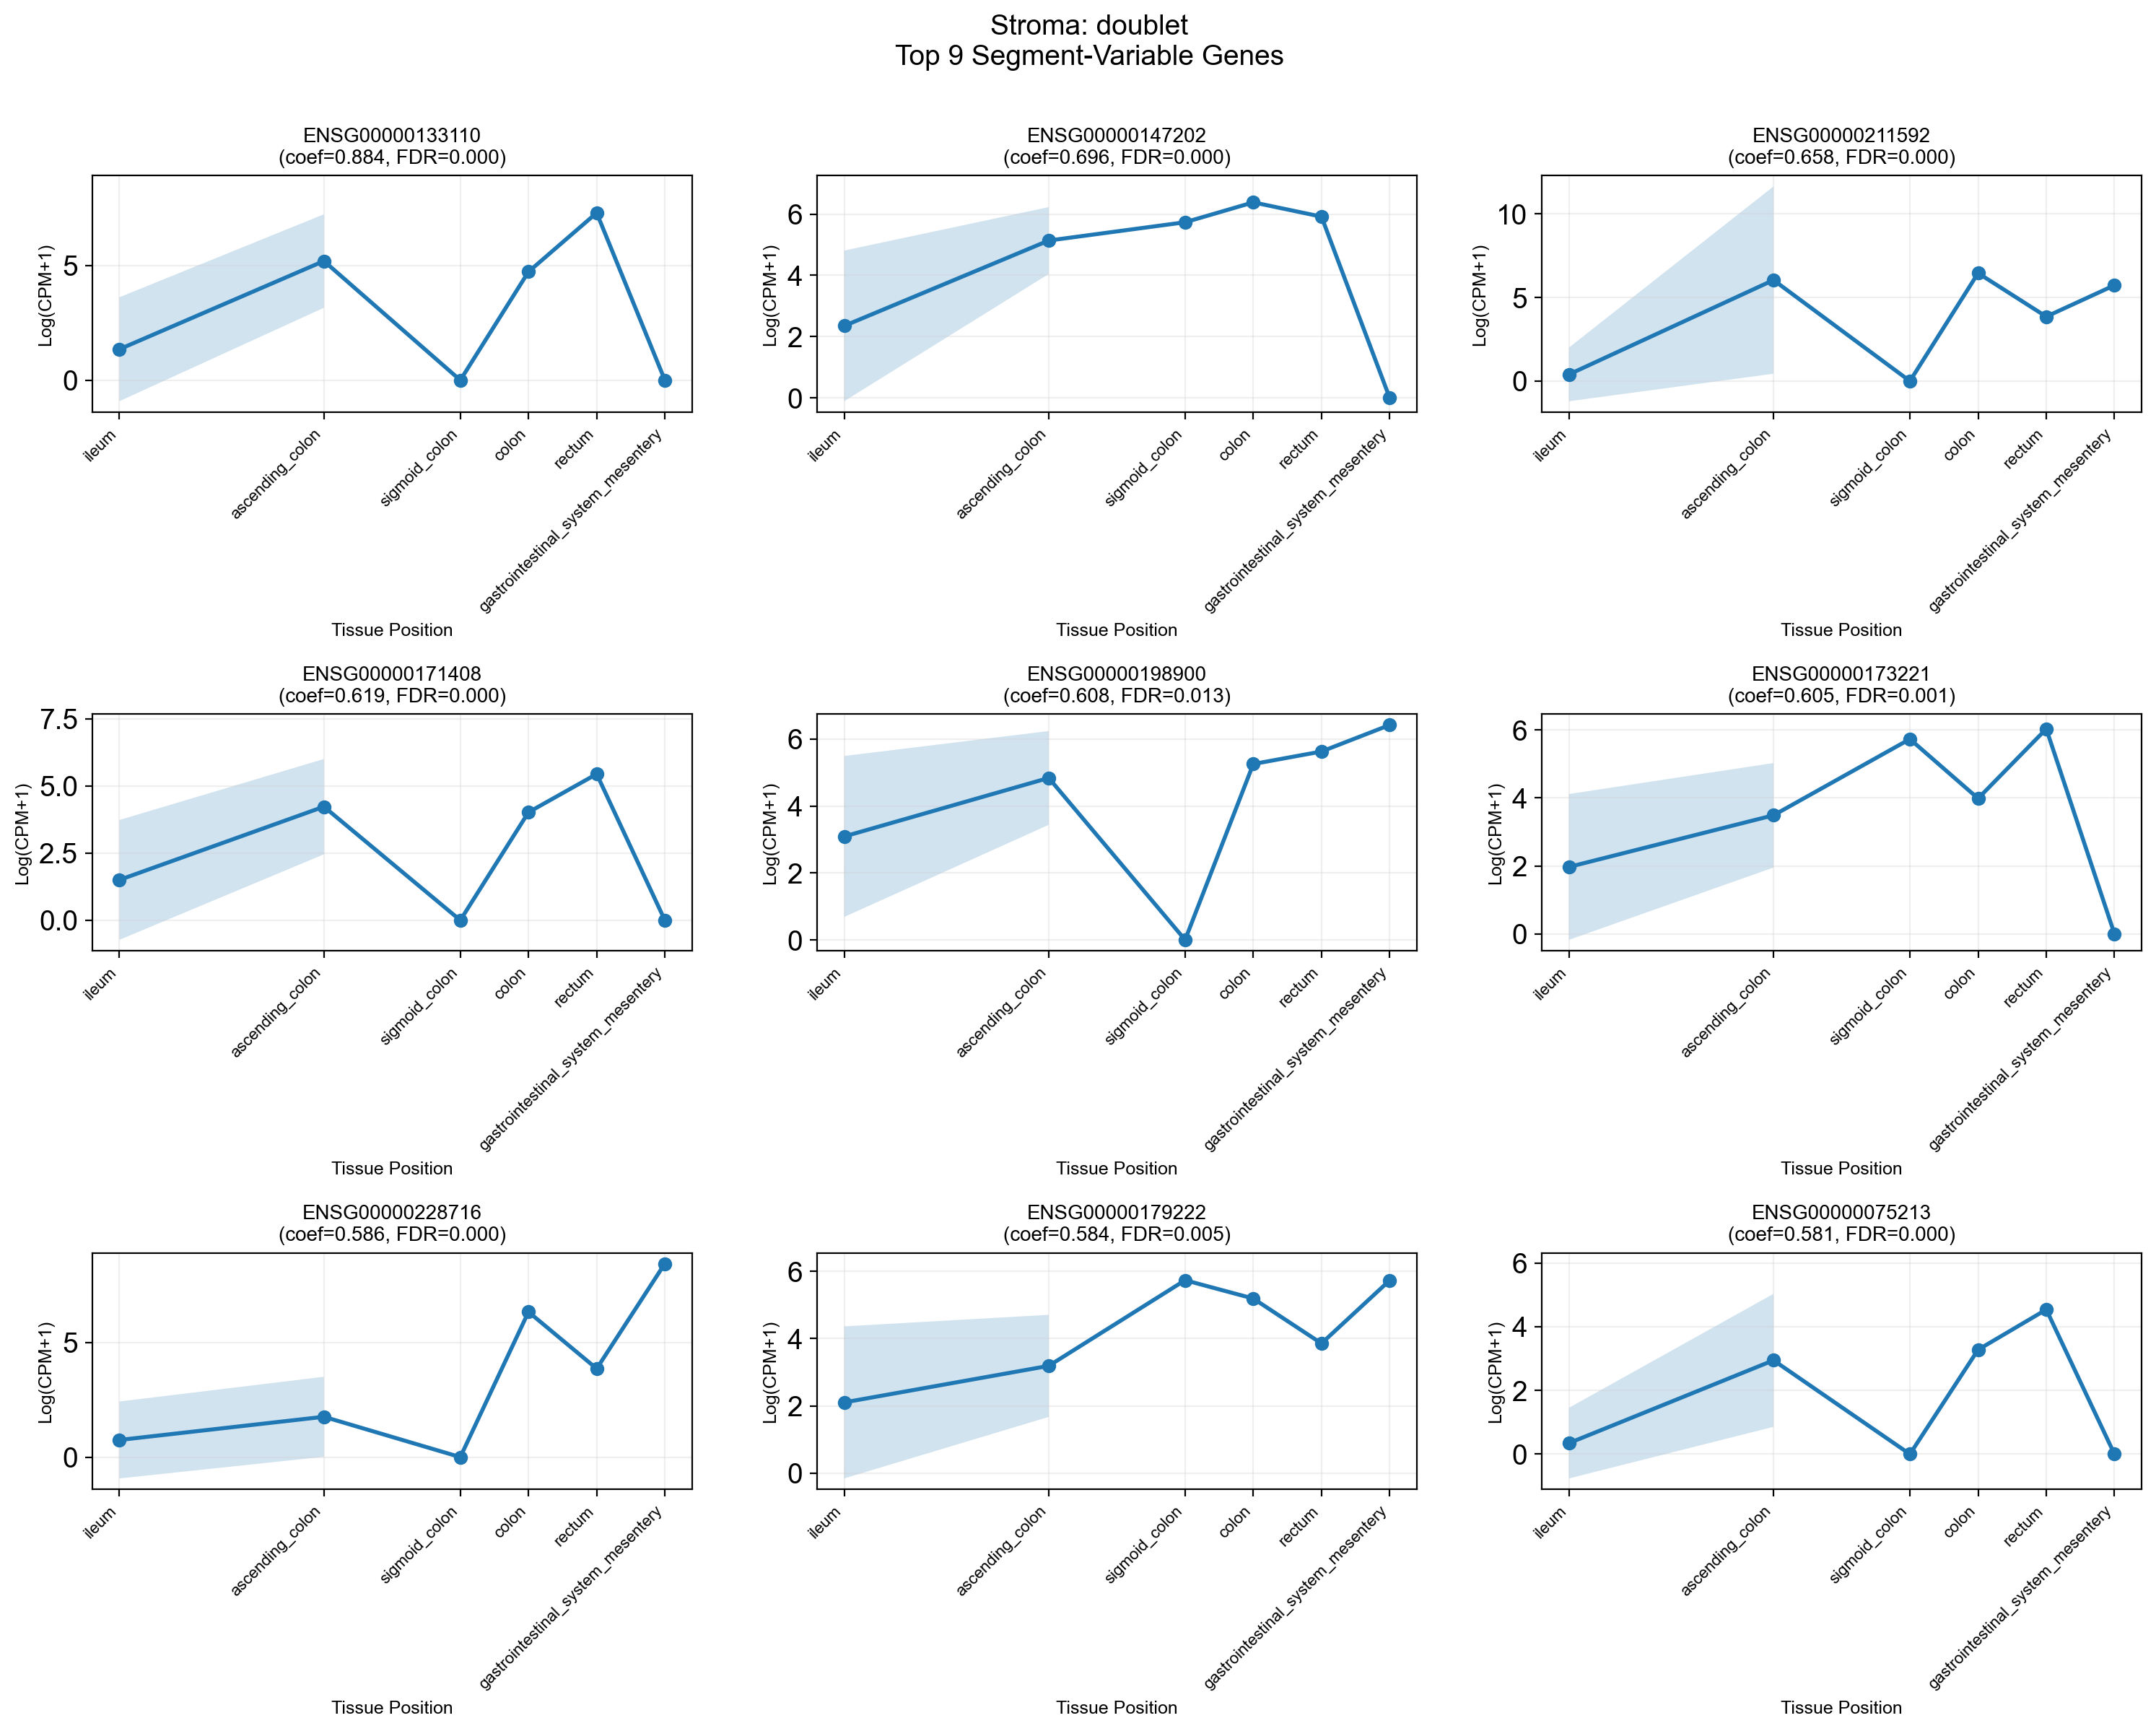

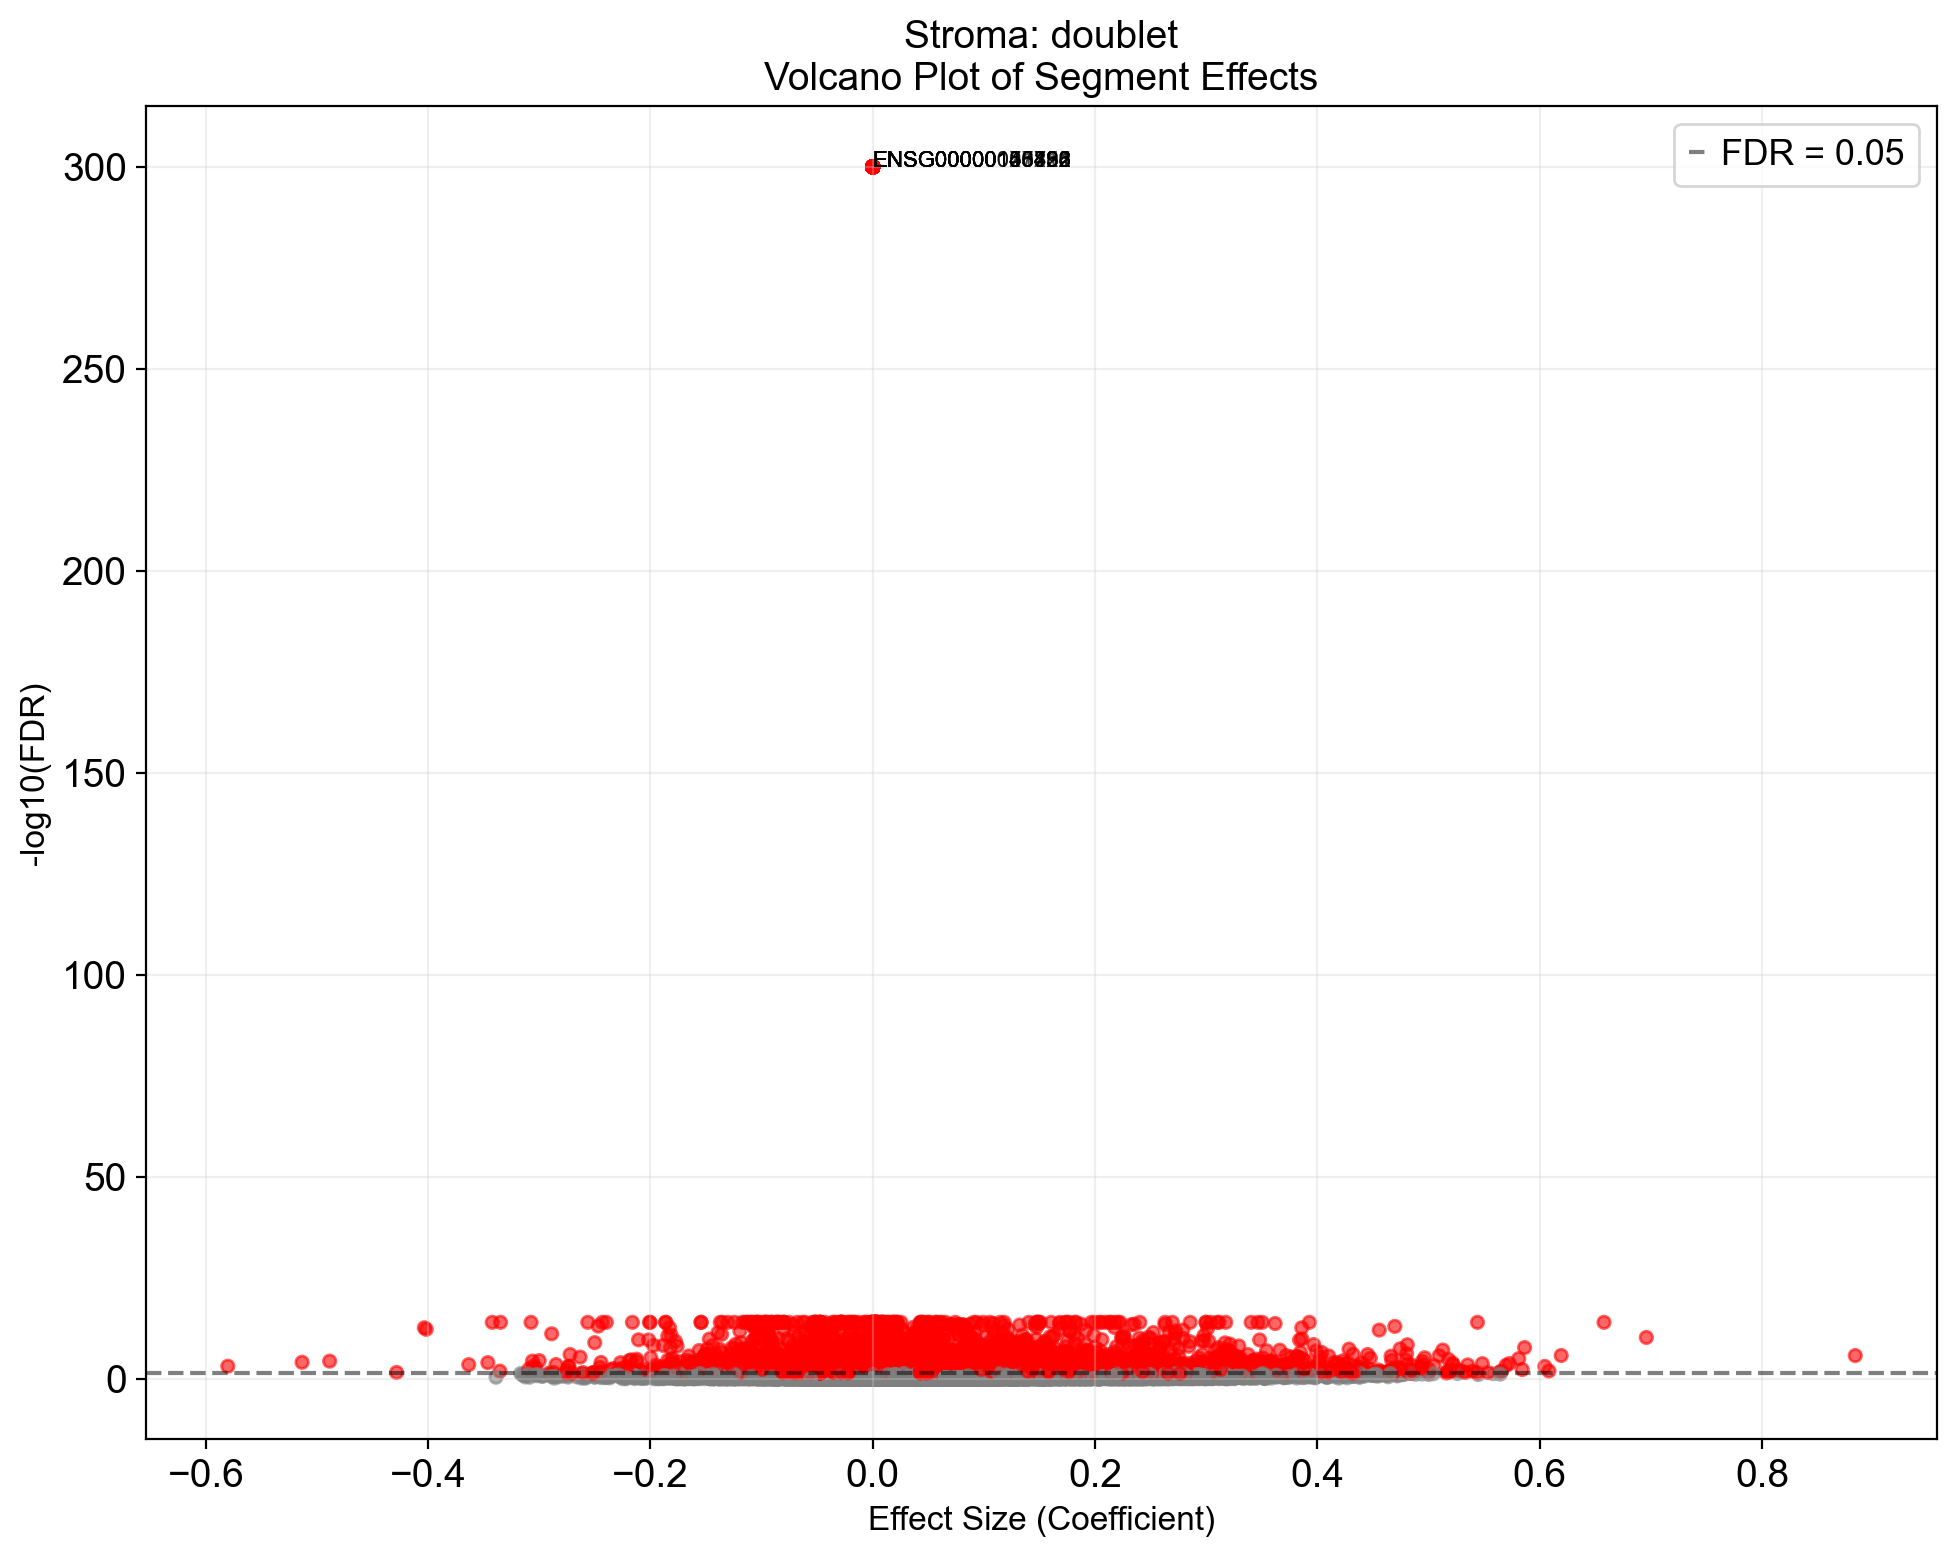

  Created plots for stroma/doublet


KeyboardInterrupt: 


KeyboardInterrupt



Error in callback <function flush_figures at 0x16bfc4a40> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [34]:
def plot_top_genes_across_tissue(pseudobulk_dict, results_df, celltype, lineage_name, top_n=10, output_dir=None):
    """Plot top N genes across tissue axis"""
    counts = pseudobulk_dict['counts']
    metadata = pseudobulk_dict['metadata']
    sample_key = metadata.columns[0]  # First column is sample key
    
    # Get top genes by absolute effect size
    top_genes = results_df.nlargest(top_n, 'abs_coef')['gene'].tolist()
    
    # Normalize counts
    total_counts = counts.sum(axis=1)
    cpm = counts.div(total_counts, axis=0) * 1e6
    log_cpm = np.log1p(cpm)
    
    # Merge with metadata
    # Ensure the index (samples) is a proper column named sample_key before merging
    log_cpm_reset = log_cpm.reset_index()
    # If the index column is not already named sample_key, rename it
    if sample_key not in log_cpm_reset.columns:
        index_col = log_cpm_reset.columns[0]
        log_cpm_reset = log_cpm_reset.rename(columns={index_col: sample_key})
    
    log_cpm_with_meta = log_cpm_reset.merge(
        metadata,
        on=sample_key,
        how='left'
    )
    
    # Filter to valid tissue orders
    log_cpm_with_meta = log_cpm_with_meta[log_cpm_with_meta['tissue_order'] < 999].copy()
    
    # Get actual tissues present in data and create reverse mapping
    present_tissue_orders = sorted(log_cpm_with_meta['tissue_order'].unique())
    order_to_tissue = {order: tissue for tissue, order in tissue_to_order.items()}
    present_tissues = [order_to_tissue.get(order, f'tissue_{order}') for order in present_tissue_orders]
    
    # Create figure
    n_cols = 3
    n_rows = (len(top_genes) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for idx, gene in enumerate(top_genes):
        ax = axes[idx]
        
        # Aggregate by tissue
        gene_data = log_cpm_with_meta[['tissue_order', gene]].groupby('tissue_order')[gene].agg(['mean', 'std']).reset_index()
        gene_data = gene_data.sort_values('tissue_order')
        
        ax.plot(
            gene_data['tissue_order'],
            gene_data['mean'],
            marker='o',
            linewidth=2,
            markersize=6
        )
        ax.fill_between(
            gene_data['tissue_order'],
            gene_data['mean'] - gene_data['std'],
            gene_data['mean'] + gene_data['std'],
            alpha=0.2
        )
        
        ax.set_title(f'{gene}\n(coef={results_df[results_df["gene"]==gene]["coef"].values[0]:.3f}, FDR={results_df[results_df["gene"]==gene]["fdr"].values[0]:.3f})', fontsize=10)
        ax.set_xlabel('Tissue Position', fontsize=9)
        ax.set_ylabel('Log(CPM+1)', fontsize=9)
        ax.set_xticks(present_tissue_orders)
        ax.set_xticklabels(present_tissues, rotation=45, ha='right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(top_genes), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{lineage_name.capitalize()}: {celltype}\nTop {top_n} Segment-Variable Genes', fontsize=14, y=1.0)
    plt.tight_layout()
    
    if output_dir:
        ct_safe = str(celltype).replace('/', '_').replace('\\', '_')
        fig.savefig(output_dir / f'{lineage_name}_{ct_safe}_top_genes.png', dpi=300, bbox_inches='tight')
    
    plt.show()

def plot_volcano(results_df, celltype, lineage_name, fdr_threshold=0.05, output_dir=None):
    """Create volcano plot for a cell type"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Calculate -log10(FDR)
    results_df = results_df.copy()
    results_df['neg_log10_fdr'] = -np.log10(results_df['fdr'] + 1e-300)
    results_df['abs_coef'] = np.abs(results_df['coef'])
    
    # Color by significance
    colors = ['red' if fdr < fdr_threshold else 'gray' for fdr in results_df['fdr']]
    
    ax.scatter(
        results_df['coef'],
        results_df['neg_log10_fdr'],
        c=colors,
        alpha=0.6,
        s=20
    )
    
    # Add threshold line
    ax.axhline(y=-np.log10(fdr_threshold), color='black', linestyle='--', alpha=0.5, label=f'FDR = {fdr_threshold}')
    
    # Label top genes
    top_genes = results_df.nsmallest(10, 'fdr')
    for _, row in top_genes.iterrows():
        ax.annotate(
            row['gene'],
            (row['coef'], row['neg_log10_fdr']),
            fontsize=8,
            alpha=0.7
        )
    
    ax.set_xlabel('Effect Size (Coefficient)', fontsize=12)
    ax.set_ylabel('-log10(FDR)', fontsize=12)
    ax.set_title(f'{lineage_name.capitalize()}: {celltype}\nVolcano Plot of Segment Effects', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if output_dir:
        ct_safe = str(celltype).replace('/', '_').replace('\\', '_')
        fig.savefig(output_dir / f'{lineage_name}_{ct_safe}_volcano.png', dpi=300, bbox_inches='tight')
    
    plt.show()

# Create visualizations for each cell type
print("\nCreating visualizations...")
for lineage_name, lineage_results in de_results.items():
    for ct, results_dict in lineage_results.items():
        results = results_dict['with_covariates'].copy()
        pseudobulk = results_dict['pseudobulk']
        
        if len(results) == 0:
            continue
        
        # Create a copy for visualization (results['gene'] contains Ensembl IDs)
        results_viz = results.copy()
        # Map gene names from Ensembl IDs to gene symbols for visualization
        results_viz['gene'] = results_viz['gene'].map(lambda x: gene_symbol_map.get(x, x))
        
        # Always update pseudobulk column names from Ensembl IDs to gene symbols
        pseudobulk_counts = pseudobulk['counts'].copy()
        pseudobulk_counts.columns = [gene_symbol_map.get(col, col) for col in pseudobulk_counts.columns]
        pseudobulk = {
            'counts': pseudobulk_counts,
            'metadata': pseudobulk['metadata']
        }
        
        # Add abs_coef for sorting
        results_viz['abs_coef'] = np.abs(results_viz['coef'])
        
        # Create plots (use results_viz which has gene symbols)
        try:
            plot_top_genes_across_tissue(pseudobulk, results_viz, ct, lineage_name, top_n=9, output_dir=output_dir)
            plot_volcano(results_viz, ct, lineage_name, fdr_threshold=0.05, output_dir=output_dir)
            print(f"  Created plots for {lineage_name}/{ct}")
        except Exception as e:
            print(f"  Warning: Failed to create plots for {lineage_name}/{ct}: {e}")

Index([], dtype='object')
Index([], dtype='object')
Index([], dtype='object')
Index([], dtype='object')


""
ENSG00000000003
ENSG00000000005
ENSG00000000419
ENSG00000000457
ENSG00000000460
...
ENSG00000288380
ENSG00000288398
ENSG00000288436
ENSG00000288459


,gene,coef,pvalue,r_squared,n_samples,fdr,abs_coef
0,ENSG00000000003,0.372168,0.235591,0.230334,46,0.749228,0.372168
1,ENSG00000000005,0.000000,1.000000,0.000000,46,1.000000,0.000000
2,ENSG00000000419,0.094149,0.890326,0.086519,46,1.000000,0.094149
3,ENSG00000000457,0.082100,0.753994,0.118503,46,1.000000,0.082100
4,ENSG00000000460,0.198015,0.490583,0.170030,46,1.000000,0.198015
...,...,...,...,...,...,...,...
36348,ENSG00000288380,0.034441,0.166191,0.253924,46,0.571231,0.034441
36349,ENSG00000288398,0.034441,0.166191,0.253924,46,0.571231,0.034441
36350,ENSG00000288436,0.067758,0.166191,0.253924,46,0.571231,0.067758
36351,ENSG00000288459,0.000000,1.000000,0.000000,46,1.000000,0.000000
